# Preliminary snRNAseq analysis
- data generated on 12/18/26
- isolated tissue from OMC of lab mouse, sorted on DAPI -> 10x
- generated ~10,000 cells

- Mostly followed the [basic tutorial from scanpy](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html) to get started


Suggested reading:
- [Single Cell Best practices GitBook](https://www.sc-best-practices.org/preamble.html)

In [1]:
# load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# snRNAseq
import anndata as ad
import scanpy as sc


# Initial exploration

In [ ]:
# specify paths
home_path = "/Volumes/S2D1/"
filt_expr_path = home_path +"Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/count/Banerjee_EI02_LM/outs/filtered_feature_bc_matrix.h5"
save_path = home_path+"Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/figs"

- uses [anndata](https://anndata.readthedocs.io/en/stable/tutorials/notebooks/getting-started.html) objects

In [ ]:
adata = sc.read_10x_h5(filt_expr_path)
adata.var_names_make_unique()
adata.var_keys

In [ ]:
expr = adata.to_df()


In [ ]:
expr_n0 = expr.replace(0, np.nan) # replace 0 w/ nan

# drop gene columns where don't detect gene counts
gene_0_idx = expr_n0.sum()==0
gene_0 = expr_n0.columns[gene_0_idx].to_list()
expr_n0 = expr_n0.drop(gene_0, axis=1)

# flattened list of all expression values
expr_vals = expr_n0.to_numpy().flatten()
expr_vals = expr_vals[~np.isnan(expr_vals)]

# sum of all gene counts per cell
cell_counts = expr_n0.sum(axis=1)

# sum of expressed genes per cell
gene_counts = (expr_n0>0).sum(axis=1)

# percent of cells expressing gene
pcells = (((expr_n0>0).sum(axis=0))/expr_n0.shape[0]) * 100


In [ ]:
# summary statistics

# number of cells
print("Number of cells:", adata.obs.shape[0])


# number of genes
print("Number of genes:", adata.var.shape[0])
print("Number of non-zero genes:", expr_n0.shape[1])


fig, axs = plt.subplots(2,2, figsize=(12,10))
# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)


######## GENE COUNTS PER CELL (exclude 0s)

log_bins = np.logspace(0,4, 15)
axs[0,0].hist(expr_vals, bins=log_bins)
axs[0,0].set_xscale('log')
axs[0,0].set_xlabel("Raw gene count")
axs[0,0].set_ylabel("Frequency")


textstr = '\n'.join((
    'Individual gene counts per cell',
    f"\tRange: {expr_vals.max():.2f} - {expr_vals.min():.2f}",
    f"\tMean +/- std: {expr_vals.mean():.2f} +/- {expr_vals.std():.2f}",
    f"\tMedian: {np.median(expr_vals):.2f}"
))

# textbox
axs[0,0].text(0.25, 0.95, textstr, transform=axs[0,0].transAxes, fontsize=14,
        verticalalignment='top', bbox=props)




##### SUMMED GENE COUNTS PER CELL

axs[0,1].hist(cell_counts)
axs[0,1].set_xlabel("Summed total gene counts per cell")
axs[0,1].set_ylabel("Frequency")

# stats on summed gene counts per cell

textstr = '\n'.join((
    'Summed gene counts per cell',
    f"\tRange: {cell_counts.max():.2f} - {cell_counts.min():.2f}",
    f"\tMean +/- std: {cell_counts.mean():.2f} +/- {cell_counts.std():.2f}",
    f"\tMedian: {np.median(cell_counts):.2f}"
))

# textbox
axs[0,1].text(0.25, 0.95, textstr, transform=axs[0,1].transAxes, fontsize=14,
        verticalalignment='top', bbox=props)





###### NUMBER OF EXPRESSED GENES PER CELL

axs[1,0].hist(gene_counts)
axs[1,0].set_xlabel("# expressed genes per cell")
axs[1,0].set_ylabel("Frequency")

textstr = '\n'.join((
    'Summed gene counts per cell',
    f"\tRange: {gene_counts.max():.2f} - {gene_counts.min():.2f}",
    f"\tMean +/- std: {gene_counts.mean():.2f} +/- {gene_counts.std():.2f}",
    f"\tMedian: {np.median(gene_counts):.2f}"
))

# textbox
axs[1,0].text(0.25, 0.95, textstr, transform=axs[1,0].transAxes, fontsize=14,
        verticalalignment='top', bbox=props)


##### PERCENT OF CELLS EXPRESSING GENE

axs[1,1].hist(pcells)
axs[1,1].set_xlabel("Percent of cells per gene")
axs[1,1].set_ylabel("Frequency")

textstr = '\n'.join((
    'Percent of cells per gene',
    f"\tRange: {pcells.max():.2f} - {pcells.min():.2f}",
    f"\tMean +/- std: {pcells.mean():.2f} +/- {pcells.std():.2f}",
    f"\tMedian: {pcells.median():.2f}"
))

# textbox
axs[1,1].text(0.25, 0.95, textstr, transform=axs[1,1].transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

plt.show()

In [ ]:
# sigmoidal relation b/w expr level and freq in cells

avg_gene_expr = expr_n0.mean()

pcells

plt.scatter(avg_gene_expr, pcells)
plt.xscale('log')
plt.xlabel("Average gene expression per cell")
plt.ylabel("Percent cells expressed")
plt.show()





# Quality control

- QC metrics taken from [McCarthy et al., 2017](https://doi.org/10.1093/bioinformatics/btw777)
- based on scater package in R/Bioconductor

In [2]:
# load data
home_path = "/Volumes/S2D1/"
filt_expr_path = home_path +"Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/count/Banerjee_EI02_LM/outs/filtered_feature_bc_matrix.h5"
save_path = home_path+"Emily/transcriptomics/snRNAseq/26Jan_snRNA_OMC_labmouse/figs"
adata = sc.read_10x_h5(filt_expr_path)

adata

/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
# 13 mitochondrial genes
mito_idx = adata.var.index.str.startswith("mt")
mito = adata.var.index[mito_idx]
print(mito)
print(f"{len(mito)} mito genes")

# ribo genes
ribo_idx = adata.var.index.str.startswith(("Rps", "Rpl"))
ribo = adata.var.index[ribo_idx]
print("\n",ribo)
print(f"{len(ribo)} ribo genes")

# Hemoglobin genes
hemo_idx = adata.var.index.str.contains("Hb[^spe]")
hemo = adata.var.index[hemo_idx]
print("\n",hemo)
print(f"{len(hemo)} hemo genes")

Index(['mt-Nd1', 'mt-Nd2', 'mt-Co1', 'mt-Co2', 'mt-Atp8', 'mt-Atp6', 'mt-Co3',
       'mt-Nd3', 'mt-Nd4l', 'mt-Nd4', 'mt-Nd5', 'mt-Nd6', 'mt-Cytb'],
      dtype='object')
13 mito genes

 Index(['Rpl7', 'Rpl31', 'Rpl37a', 'Rps6kc1', 'Rpl7a', 'Rpl12', 'Rpl35',
       'Rps21', 'Rpl22l1', 'Rps3a1',
       ...
       'Rpl17', 'Rps6kb2', 'Rps6ka4', 'Rpl9-ps6', 'Rpl39', 'Rpl10', 'Rps4x',
       'Rps6ka6', 'Rpl36a', 'Rps6ka3'],
      dtype='object', length=101)
101 ribo genes

 Index(['Hbb-bt', 'Hbb-bs', 'Hbb-bh2', 'Hbb-bh1', 'Hbb-y', 'Hba-x', 'Hba-a1',
       'Hbq1b', 'Hba-a2', 'Hbq1a'],
      dtype='object')
10 hemo genes


In [5]:
# Mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("mt-")

# Ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))

# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("Hb[^spe]")

In [6]:
# Scanpy, preprocess, QC
# note: log1p = natural log of x+1
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
adata.var_keys

<bound method AnnData.var_keys of AnnData object with n_obs × n_vars = 24825 × 32285
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'>

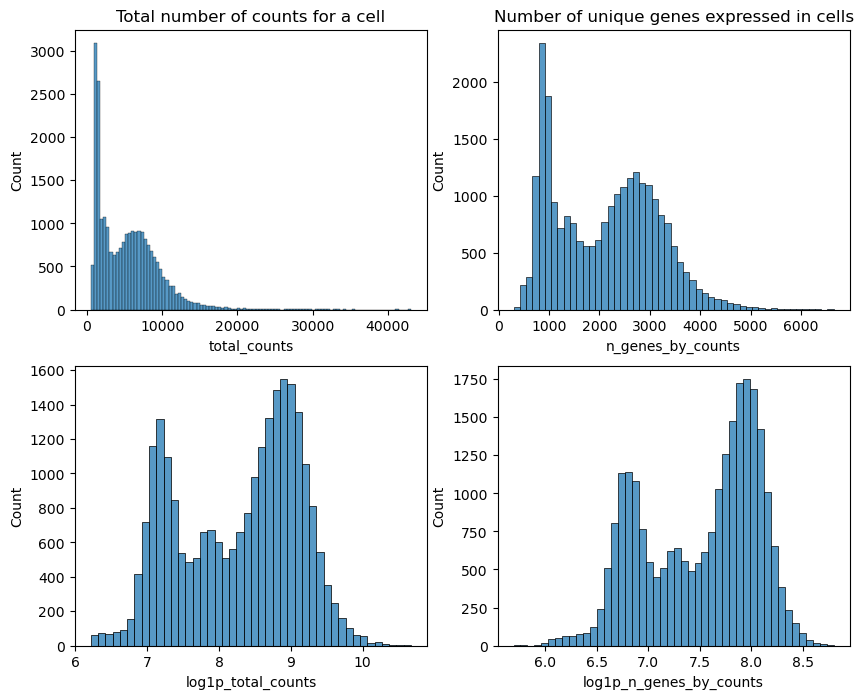

In [7]:
# sns.jointplot(
#     data=adata.obs,
#     x="total_counts",
#     y="n_genes_by_counts",
#     kind="hex"
#     )

# plt.show()

# sns.jointplot(
#     data=adata.obs,
#     x="log1p_total_counts",
#     y="log1p_n_genes_by_counts",
#     kind="hex"
#     )

# plt.show()

fig, axs = plt.subplots(2,2, figsize=(10,8))

sns.histplot(adata.obs["total_counts"], ax=axs[0,0])
axs[0,0].set_title("Total number of counts for a cell")

sns.histplot(adata.obs["n_genes_by_counts"], ax=axs[0,1])
axs[0,1].set_title("Number of unique genes expressed in cells")

sns.histplot(adata.obs["log1p_total_counts"], ax=axs[1,0])

sns.histplot(adata.obs["log1p_n_genes_by_counts"], ax=axs[1,1])

plt.show()

In [ ]:
sns.ecdfplot(adata.obs, x="log1p_total_counts")
plt.show()


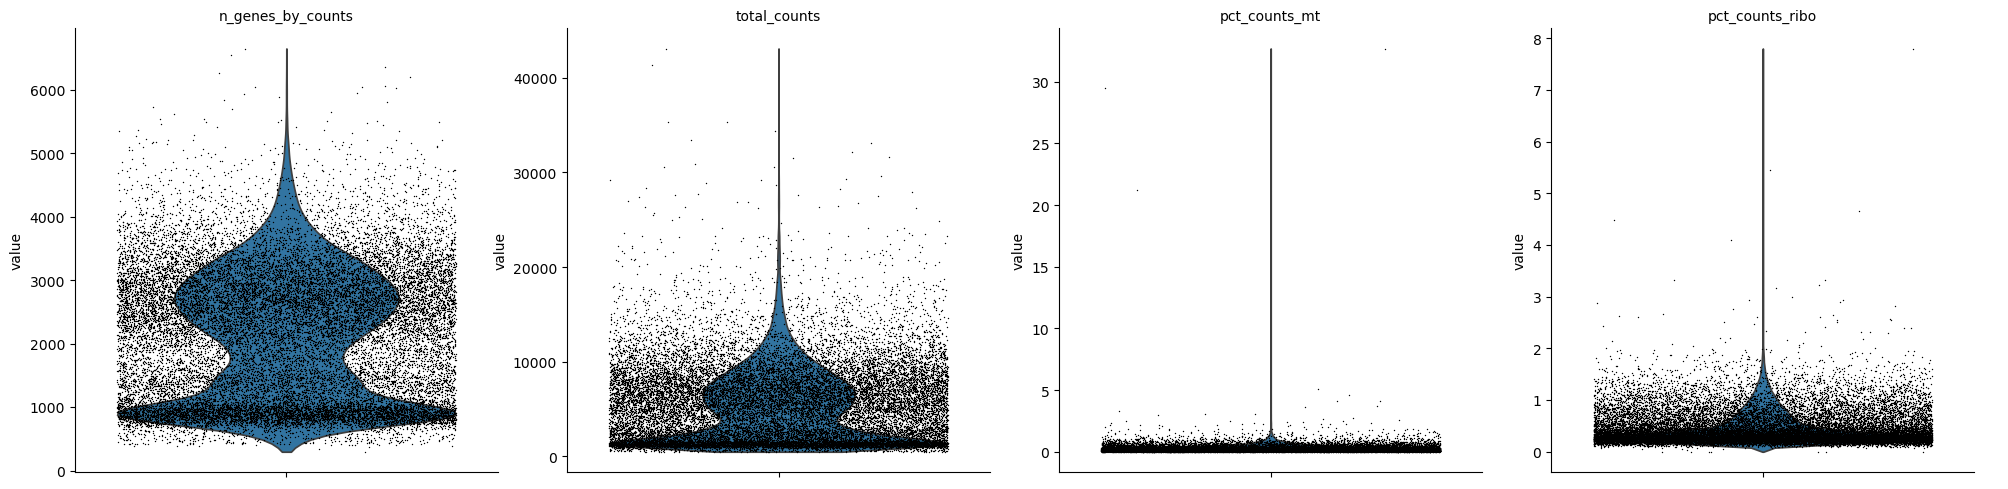

In [9]:
# scanpy, plotting, violin
adata.var_names_make_unique()
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)

<>:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/p6/sybd66w15k9_sz65dtgk6hym0000gp/T/ipykernel_38010/3106792241.py:8: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  axes.text(np.log1p(3), 20000, "$\geq$3 genes per cell")


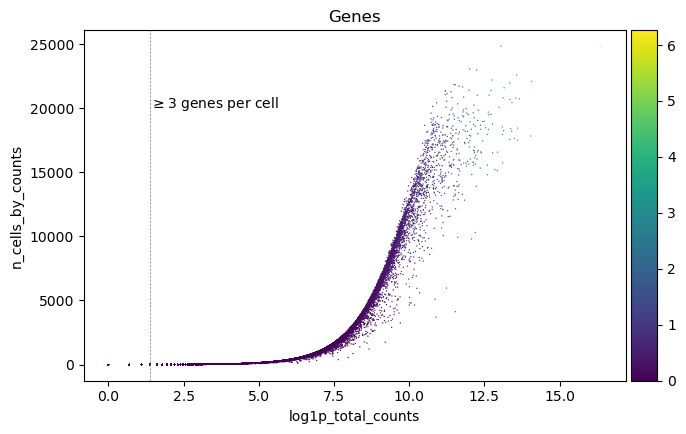

In [10]:
axes = sc.pl.scatter(adata, "log1p_total_counts", "n_cells_by_counts", color="log1p_mean_counts", show=False)
# pct_counts_ribo = proportion of total counts for a cell which are ribosomal
# note, uses color to determine whether plotting obs or var

# axes.axhline(300, c="grey", ls="--", lw=0.5) # soft cut-off of at least 300 genes detected per cell
axes.axvline(np.log1p(3), c="grey", ls="--", lw=0.5) # soft cut-off of at least 1000 counts per cell
axes.set_title("Genes")
axes.text(np.log1p(3), 20000, "$\geq$3 genes per cell")
plt.show()


<>:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/p6/sybd66w15k9_sz65dtgk6hym0000gp/T/ipykernel_38010/3505412505.py:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  axes.text(2000, 6000, "$\geq$2000 counts per cell")


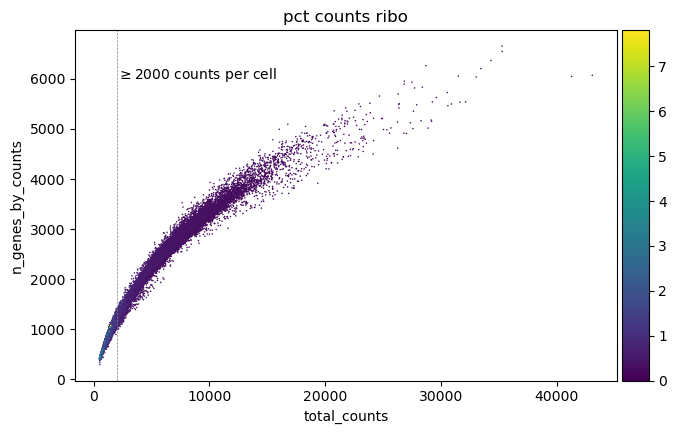

In [11]:
axes = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_ribo", show=False)
# pct_counts_ribo = proportion of total counts for a cell which are ribosomal
# note, uses color to determine whether plotting obs or var

# axes.axhline(300, c="grey", ls="--", lw=0.5) # soft cut-off of at least 300 genes detected per cell
axes.axvline(2000, c="grey", ls="--", lw=0.5) # soft cut-off of at least 1000 counts per cell
axes.text(2000, 6000, "$\geq$2000 counts per cell")
plt.show()



# Filtering
- Filtering, decided on >2000 gene counts per cell (as observed in Allen)
- Filtering, decided on >3 cell counts per gene (as seen in scanpy tutorial)

In [12]:
# number of cells w/ total gene counts > 2000
cells_pass = sum(adata.obs["total_counts"]>2000)
print(f"{cells_pass}/{adata.n_obs} cells pass")

# number of genes w/ total cell counts > 3
genes_pass = sum(adata.var["total_counts"]>3)
print(f"{genes_pass}/{adata.n_vars} genes pass")

17885/24825 cells pass
23508/32285 genes pass


In [ ]:
sc.pp.filter_cells(adata, min_counts=2000)
sc.pp.filter_genes(adata, min_cells=3)
adata

# Doublet detection
- uses scrublet method for detected droublets
- see [Wolock et al., 2019](https://doi.org/10.1016/j.cels.2018.11.005)
- Uses nearest-neighbor classifer of transcriptomes and simulated doublets
- produces linear combinations of transcriptomes of random sample of combined cells across clusters, compares to other cells/clusters to determine if doublet
-  `sc.pp.scrublet` adds `predicted_doublet` and `doublet`score to `.obs`

- Alternative methods for doublet detection: [DoubletDetection](https://github.com/JonathanShor/DoubletDetection) and [SOLO](https://docs.scvi-tools.org/en/stable/user_guide/models/solo.html)
    - See: [Doublet Detection Chapter](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html#doublet-detection)

In [13]:
sc.pp.scrublet(adata)
adata

AnnData object with n_obs × n_vars = 24825 × 32285
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scrublet'

In [14]:
print(f"Number of predicted doublets: {sum(adata.obs["predicted_doublet"])}")

Number of predicted doublets: 1214
